# 01 Crime + Safety Wrangling

This notebook cleans crime data for the San Diego Neighborhood Opportunity Finder project.

The goal is to create tract-level safety features that can be joined with the ACS tract dataset. Safety is one of the most important parts of the final opportunity score, so this notebook focuses on crime counts, violent crime, property crime, and crime rates by population.

The final output will be:

`crime_safety_by_tract.csv`

This file will include one row per census tract and safety-related features that can be used later in EDA, scoring, and modeling.

In [1]:
# importing libraries for data cleaning and spatial work
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path

# showing more columns so inspection is easier
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

# setting up file paths
data_dir = Path('../data')
raw_dir = data_dir / 'raw'
processed_dir = data_dir / 'processed'

raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

# input files
acs_path = processed_dir / 'acs_tracts_selected_2024.csv'

# output file
crime_output_path = processed_dir / 'crime_safety_by_tract.csv'

## Load the crime data

I am starting with 2024 crime data because the ACS file is also from 2024. This keeps the crime and demographic data closer in time.

The raw crime file is from the City of San Diego Police NIBRS Crime Offenses dataset.

In [2]:
crime_url_2024 = 'https://seshat.datasd.org/police_nibrs/pd_nibrs_2024_datasd.csv'

In [3]:
# loading 2024 SDPD NIBRS crime data
crime_raw = pd.read_csv(crime_url_2024)

# checking the basic shape
crime_raw.shape

(80636, 30)

In [4]:
# looking at the first few rows
crime_raw.head()

,objectid,nibrs_uniq,case_number,occured_on,approved_on,day_of_week,month,year,code_section,group_type,ibr_category,crime_against,ibr_offense,ibr_offense_description,pd_offense_category,violent_crime,property_crime,beat,neighborhood,service_area,division_number,division,block_addr,city,state,zip,geocode_status,geocode_score,latitude,longitude
0,26924,3123808_520,23034358,2024-07-27,2024-07-29 05:03:53,7,7,2024,29800 (A)(1) PC FELON/ADDICT/POSSESS/ETC FIREA...,A,WEAPON LAW VIOLATIONS,SO,520,Weapon Law Violations,Weapon Law Violations,0,0,446,Lincoln Park,440.0,4.0,Southeastern,100 47th ST,San Diego,CA,92102.0,M,95.83,32.704172,-117.093782
1,76230,3125374_240_1,23304390,2024-08-22,2024-08-22 15:28:17,5,8,2024,10851 (A) VC TAKE VEHICLE W/O OWNER'S CONSENT/...,A,MOTOR VEHICLE THEFT,PR,240,Motor Vehicle Theft,Motor Vehicle Theft,0,1,834,Castle,830.0,8.0,Mid-City,3300 Marlesta DR,San Diego,CA,92111.0,M,96.55,32.805593,-117.174030
2,130710,2898215_13A_9,21035164,2024-03-02,2024-03-04 10:47:20,7,3,2024,246 PC SHOOT AT INHABITED DWELLING/VEH (F) ||,A,ASSAULT OFFENSES,PE,13A,Aggravated Assault,Aggravated Assault,1,0,432,Valencia Park,430.0,4.0,Southeastern,5300 El Cajon BLVD,SD,CA,92105.0,M,100.00,32.757541,-117.081825
3,145385,2898215_13A_20,21035164,2024-03-02,2024-03-04 10:47:20,7,3,2024,246 PC SHOOT AT INHABITED DWELLING/VEH (F) ||,A,ASSAULT OFFENSES,PE,13A,Aggravated Assault,Aggravated Assault,1,0,432,Valencia Park,430.0,4.0,Southeastern,5300 El Cajon BLVD,SD,CA,92105.0,M,100.00,32.757541,-117.081825
4,153038,3061417_240_1,23300435,2024-07-10,2024-07-11 00:11:26,4,7,2024,10851 (A) VC TAKE VEHICLE W/O OWNER'S CONSENT/...,A,MOTOR VEHICLE THEFT,PR,240,Motor Vehicle Theft,Motor Vehicle Theft,0,1,518,South Park,510.0,5.0,Central,3800 Central AVE,San Diego,CA,92105.0,M,96.55,32.747867,-117.108254


In [5]:
# checking columns and data types
crime_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 80636 entries, 0 to 80635
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   objectid                 80636 non-null  int64  
 1   nibrs_uniq               80636 non-null  str    
 2   case_number              80636 non-null  int64  
 3   occured_on               80636 non-null  str    
 4   approved_on              80630 non-null  str    
 5   day_of_week              80636 non-null  int64  
 6   month                    80636 non-null  int64  
 7   year                     80636 non-null  int64  
 8   code_section             80630 non-null  str    
 9   group_type               80636 non-null  str    
 10  ibr_category             80636 non-null  str    
 11  crime_against            63914 non-null  str    
 12  ibr_offense              80636 non-null  str    
 13  ibr_offense_description  80636 non-null  str    
 14  pd_offense_category      80636 no

In [6]:
# checking missing values
missing_crime = crime_raw.isna().mean().sort_values(ascending=False)

missing_crime.head(25)

crime_against              0.207376
block_addr                 0.061027
longitude                  0.032157
latitude                   0.032157
city                       0.019309
division_number            0.006350
service_area               0.006350
zip                        0.003708
state                      0.000198
division                   0.000099
code_section               0.000074
approved_on                0.000074
nibrs_uniq                 0.000000
case_number                0.000000
ibr_offense_description    0.000000
ibr_offense                0.000000
ibr_category               0.000000
group_type                 0.000000
month                      0.000000
year                       0.000000
occured_on                 0.000000
day_of_week                0.000000
objectid                   0.000000
neighborhood               0.000000
property_crime             0.000000
dtype: float64

In [7]:
# checking the main crime category fields
crime_raw[['ibr_category', 'crime_against', 'pd_offense_category', 'violent_crime', 'property_crime']].head()

,ibr_category,crime_against,pd_offense_category,violent_crime,property_crime
0,WEAPON LAW VIOLATIONS,SO,Weapon Law Violations,0,0
1,MOTOR VEHICLE THEFT,PR,Motor Vehicle Theft,0,1
2,ASSAULT OFFENSES,PE,Aggravated Assault,1,0
3,ASSAULT OFFENSES,PE,Aggravated Assault,1,0
4,MOTOR VEHICLE THEFT,PR,Motor Vehicle Theft,0,1


In [8]:
# checking coordinate quality before joining to tracts
coord_check = crime_raw[['latitude', 'longitude', 'geocode_status', 'geocode_score']].isna().mean()

coord_check

latitude          0.032157
longitude         0.032157
geocode_status    0.000000
geocode_score     0.000000
dtype: float64

In [9]:
score_cols = [
    'violent_crime',
    'property_crime',
    'crime_against',
    'ibr_category',
    'pd_offense_category'
]

crime_raw[score_cols].describe(include='all')

,violent_crime,property_crime,crime_against,ibr_category,pd_offense_category
count,80636.000000,80636.000000,63914,80636,80636
unique,NaN,NaN,3,25,26
top,NaN,NaN,PR,"GROUP ""B"" OFFENSES",All Other Offenses
freq,NaN,NaN,37224,21492,17055
mean,0.074942,0.313297,NaN,NaN,NaN
std,0.263299,0.463837,NaN,NaN,NaN
min,0.000000,0.000000,NaN,NaN,NaN
25%,0.000000,0.000000,NaN,NaN,NaN
50%,0.000000,0.000000,NaN,NaN,NaN
75%,0.000000,1.000000,NaN,NaN,NaN


## Inspect crime categories

Before creating the safety score, I want to see which crime categories show up the most. 

It will help me figure out whether to use all crimes, only violent and property crimes, or a smaller set of categories that better match neighborhood safety.

In [10]:
# checking crime_against category counts
crime_raw['crime_against'].value_counts(dropna=False)

crime_against
PR     37224
NaN    16722
PE     13741
SO     12949
Name: count, dtype: int64

In [11]:
# checking NIBRS category counts
crime_raw['ibr_category'].value_counts(dropna=False).head(30)

ibr_category
GROUP "B" OFFENSES                          21492
LARCENY/THEFT OFFENSES                      17129
ASSAULT OFFENSES                            12600
DRUG/NARCOTIC OFFENSES                       7069
DESTRUCTION/DAMAGE/VANDALISM OF PROPERTY     6660
MOTOR VEHICLE THEFT                          5447
BURGLARY/BREAKING & ENTERING                 2687
FRAUD OFFENSES                               2662
ROBBERY                                      1080
WEAPON LAW VIOLATIONS                         983
STOLEN PROPERTY OFFENSES                      947
SEX OFFENSES, FORCIBLE                        802
COUNTERFEITING/FORGERY                        231
EMBEZZLEMENT                                  164
KIDNAPING/ABDUCTION                           154
ARSON                                         141
KIDNAPPING/ABDUCTION                          106
EXTORTION/BLACKMAIL                            76
PROSTITUTION OFFENSES                          76
HOMICIDE OFFENSES                    

In [12]:
# checking SDPD offense category counts
crime_raw['pd_offense_category'].value_counts(dropna=False).head(30)

pd_offense_category
All Other Offenses                      17055
Larceny                                 12167
Drug/Narcotic Violations                 7069
Simple Assault                           6995
Vandalism                                6660
Motor Vehicle Theft                      5447
Theft From Motor Vehicle                 4962
Aggravated Assault                       4539
Fraud/Counterfeiting                     3133
Burglary/Breaking & Entering             2687
Disorderly Conduct                       2634
Alcohol Violations                       1559
Robbery                                  1080
Intimidation                             1066
Weapon Law Violations                     983
Stolen Property Offenses                  947
Sexual Assault                            802
Kidnapping/Abduction                      266
Curfew/Loitering/Vagrancy Violations      244
Arson                                     141
Prostitution                               76
Homicide      

In [13]:
# checking which categories are counted as violent crime
violent_by_category = (
    crime_raw
    .groupby('pd_offense_category')['violent_crime']
    .agg(['count', 'sum', 'mean'])
    .sort_values('sum', ascending=False))

violent_by_category.head(20)

,count,sum,mean
pd_offense_category,,,
Aggravated Assault,4539,4539,1.000000
Robbery,1080,1080,1.000000
Sexual Assault,802,375,0.467581
Homicide,49,49,1.000000
All Other Offenses,17055,0,0.000000
Burglary/Breaking & Entering,2687,0,0.000000
Curfew/Loitering/Vagrancy Violations,244,0,0.000000
Animal Cruelty,25,0,0.000000
Arson,141,0,0.000000


In [14]:
# checking which categories are counted as property crime
property_by_category = (
    crime_raw
    .groupby('pd_offense_category')['property_crime']
    .agg(['count', 'sum', 'mean'])
    .sort_values('sum', ascending=False))

property_by_category.head(20)

,count,sum,mean
pd_offense_category,,,
Larceny,12167,12167,1.0
Motor Vehicle Theft,5447,5447,1.0
Theft From Motor Vehicle,4962,4962,1.0
Burglary/Breaking & Entering,2687,2687,1.0
Alcohol Violations,1559,0,0.0
Arson,141,0,0.0
Curfew/Loitering/Vagrancy Violations,244,0,0.0
All Other Offenses,17055,0,0.0
Animal Cruelty,25,0,0.0


## Safety score category

Since the dataset has violent crime and property crime flags, I can use those categories toward the safety score.

For this project:

- `total_crime_count` will count all reported offenses
- `violent_crime_count` will use the `violent_crime` flag
- `property_crime_count` will use the `property_crime` flag

The final safety score will use crime rates, not just raw counts, so larger tracts are not automatically treated as less safe just because more people live there.

In [15]:
# checking coordinate missing values
crime_raw[['latitude', 'longitude']].isna().mean()

latitude     0.032157
longitude    0.032157
dtype: float64

In [16]:
# checking geocode status counts
crime_raw['geocode_status'].value_counts(dropna=False)

geocode_status
M    77292
U     2593
T      751
Name: count, dtype: int64

In [17]:
# checking geocode score distribution
crime_raw['geocode_score'].describe()

count    80636.000000
mean        94.050462
std         17.485440
min          0.000000
25%         96.000000
50%         96.880000
75%        100.000000
max        100.000000
Name: geocode_score, dtype: float64

In [18]:
# records with missing or weak location data
crime_raw[
    crime_raw['latitude'].isna() |
    crime_raw['longitude'].isna() |
    (crime_raw['geocode_status'] != 'M')][['occured_on', 'pd_offense_category', 'geocode_status', 'geocode_score', 'latitude', 'longitude']].head(10)

,occured_on,pd_offense_category,geocode_status,geocode_score,latitude,longitude
9,2024-10-18,Motor Vehicle Theft,U,0.00,NaN,NaN
18,2024-09-11,Motor Vehicle Theft,U,0.00,NaN,NaN
27,2024-01-12,Larceny,T,90.87,32.557008,-117.058126
28,2024-03-19,Theft From Motor Vehicle,U,0.00,NaN,NaN
51,2024-01-01,Disorderly Conduct,T,100.00,32.719994,-117.165625
54,2024-01-01,Disorderly Conduct,U,0.00,NaN,NaN
65,2024-01-01,Simple Assault,U,0.00,NaN,NaN
77,2024-01-01,Disorderly Conduct,T,100.00,32.711582,-117.166532
78,2024-01-01,All Other Offenses,T,100.00,32.711582,-117.166532
93,2024-01-01,Intimidation,U,0.00,NaN,NaN


## Clean crime records for mapping

I'm only keeping records with matched geocodes so I don't accidently assign crimes to the wrong tract. I'll end up losing some records, but the data we do have is reliable.

In [19]:
# keeping records with matched geocodes and usable coordinates
crime_clean = crime_raw[
    (crime_raw['geocode_status'] == 'M') &
    (crime_raw['latitude'].notna()) &
    (crime_raw['longitude'].notna())].copy()

crime_clean.shape

(77292, 30)

In [20]:
# checking how much crime data was kept after location cleaning
records_before = len(crime_raw)
records_after = len(crime_clean)
records_dropped = records_before - records_after
pct_dropped = records_dropped / records_before * 100

records_before, records_after, records_dropped, pct_dropped

(80636, 77292, 3344, 4.147031102733271)

In [21]:
# columns for safety scoring and mapping
crime_clean = crime_clean[
    [
        'nibrs_uniq',
        'occured_on',
        'year',
        'month',
        'pd_offense_category',
        'violent_crime',
        'property_crime',
        'latitude',
        'longitude',
        'neighborhood',
        'zip']].copy()

crime_clean.head()

,nibrs_uniq,occured_on,year,month,pd_offense_category,violent_crime,property_crime,latitude,longitude,neighborhood,zip
0,3123808_520,2024-07-27,2024,7,Weapon Law Violations,0,0,32.704172,-117.093782,Lincoln Park,92102.0
1,3125374_240_1,2024-08-22,2024,8,Motor Vehicle Theft,0,1,32.805593,-117.174030,Castle,92111.0
2,2898215_13A_9,2024-03-02,2024,3,Aggravated Assault,1,0,32.757541,-117.081825,Valencia Park,92105.0
3,2898215_13A_20,2024-03-02,2024,3,Aggravated Assault,1,0,32.757541,-117.081825,Valencia Park,92105.0
4,3061417_240_1,2024-07-10,2024,7,Motor Vehicle Theft,0,1,32.747867,-117.108254,South Park,92105.0


In [22]:
# checking cleaned crime data
crime_clean.info()

<class 'pandas.DataFrame'>
Index: 77292 entries, 0 to 80635
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   nibrs_uniq           77292 non-null  str    
 1   occured_on           77292 non-null  str    
 2   year                 77292 non-null  int64  
 3   month                77292 non-null  int64  
 4   pd_offense_category  77292 non-null  str    
 5   violent_crime        77292 non-null  int64  
 6   property_crime       77292 non-null  int64  
 7   latitude             77292 non-null  float64
 8   longitude            77292 non-null  float64
 9   neighborhood         77292 non-null  str    
 10  zip                  77045 non-null  float64
dtypes: float64(3), int64(4), str(4)
memory usage: 7.1 MB


In [23]:
# checking missing values after cleaning
crime_clean.isna().mean().sort_values(ascending=False)

zip                    0.003196
occured_on             0.000000
nibrs_uniq             0.000000
year                   0.000000
month                  0.000000
violent_crime          0.000000
pd_offense_category    0.000000
property_crime         0.000000
latitude               0.000000
longitude              0.000000
neighborhood           0.000000
dtype: float64

In [24]:
# converting crime records into map points
crime_gdf = gpd.GeoDataFrame(
    crime_clean,
    geometry=gpd.points_from_xy(crime_clean['longitude'], crime_clean['latitude']),
    crs='EPSG:4326')

crime_gdf.head()

,nibrs_uniq,occured_on,year,month,pd_offense_category,violent_crime,property_crime,latitude,longitude,neighborhood,zip,geometry
0,3123808_520,2024-07-27,2024,7,Weapon Law Violations,0,0,32.704172,-117.093782,Lincoln Park,92102.0,POINT (-117.09378 32.70417)
1,3125374_240_1,2024-08-22,2024,8,Motor Vehicle Theft,0,1,32.805593,-117.174030,Castle,92111.0,POINT (-117.17403 32.80559)
2,2898215_13A_9,2024-03-02,2024,3,Aggravated Assault,1,0,32.757541,-117.081825,Valencia Park,92105.0,POINT (-117.08182 32.75754)
3,2898215_13A_20,2024-03-02,2024,3,Aggravated Assault,1,0,32.757541,-117.081825,Valencia Park,92105.0,POINT (-117.08182 32.75754)
4,3061417_240_1,2024-07-10,2024,7,Motor Vehicle Theft,0,1,32.747867,-117.108254,South Park,92105.0,POINT (-117.10825 32.74787)


In [25]:
# checking the crime GeoDataFrame
crime_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 77292 entries, 0 to 80635
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   nibrs_uniq           77292 non-null  str     
 1   occured_on           77292 non-null  str     
 2   year                 77292 non-null  int64   
 3   month                77292 non-null  int64   
 4   pd_offense_category  77292 non-null  str     
 5   violent_crime        77292 non-null  int64   
 6   property_crime       77292 non-null  int64   
 7   latitude             77292 non-null  float64 
 8   longitude            77292 non-null  float64 
 9   neighborhood         77292 non-null  str     
 10  zip                  77045 non-null  float64 
 11  geometry             77292 non-null  geometry
dtypes: float64(3), geometry(1), int64(4), str(4)
memory usage: 7.7 MB


<Axes: >

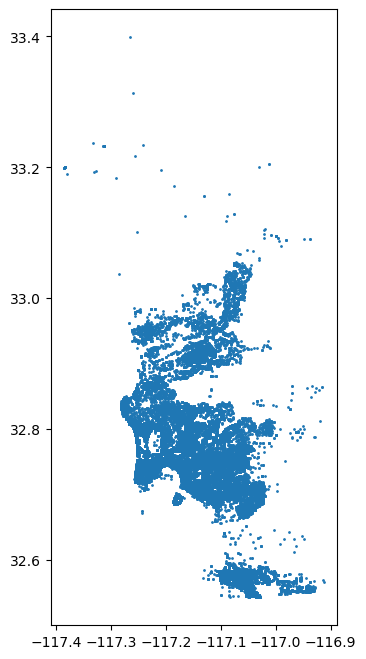

In [26]:
# quick map check to make sure the points look reasonable
crime_gdf.plot(markersize=1, figsize=(8, 8))

## Load census tract boundaries

To connect the crime records to the census tracts, I need to figure out the boundary polygons. I'm using the 2024 Census TIGER/Line tract file for California, then going to filter it to San Diego County.

In [27]:
# loading California census tract boundaries
tracts_url = 'https://www2.census.gov/geo/tiger/TIGER2024/TRACT/tl_2024_06_tract.zip'

tracts_gdf = gpd.read_file(tracts_url)

tracts_gdf.shape

(9129, 14)

In [28]:
# checking tract boundary columns
tracts_gdf.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,06,001,442700,06001442700,1400000US06001442700,4427,Census Tract 4427,G5020,S,1234016,0,+37.5371513,-122.0081095,"POLYGON ((-122.01721 37.53932, -122.01719 37.5..."
1,06,001,442800,06001442800,1400000US06001442800,4428,Census Tract 4428,G5020,S,1278646,0,+37.5293619,-121.9931002,"POLYGON ((-122.0023 37.52984, -122.00224 37.52..."
2,06,037,204920,06037204920,1400000US06037204920,2049.20,Census Tract 2049.20,G5020,S,909972,0,+34.0175004,-118.1974975,"POLYGON ((-118.20284 34.01966, -118.20283 34.0..."
3,06,037,205110,06037205110,1400000US06037205110,2051.10,Census Tract 2051.10,G5020,S,286962,0,+34.0245059,-118.2142985,"POLYGON ((-118.21964 34.02628, -118.21945 34.0..."
4,06,037,205120,06037205120,1400000US06037205120,2051.20,Census Tract 2051.20,G5020,S,1466242,0,+34.0187542,-118.2117951,"POLYGON ((-118.22023 34.02056, -118.22018 34.0..."


In [29]:
# checking tract boundary data types
tracts_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 9129 entries, 0 to 9128
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   STATEFP   9129 non-null   str     
 1   COUNTYFP  9129 non-null   str     
 2   TRACTCE   9129 non-null   str     
 3   GEOID     9129 non-null   str     
 4   GEOIDFQ   9129 non-null   str     
 5   NAME      9129 non-null   str     
 6   NAMELSAD  9129 non-null   str     
 7   MTFCC     9129 non-null   str     
 8   FUNCSTAT  9129 non-null   str     
 9   ALAND     9129 non-null   int64   
 10  AWATER    9129 non-null   int64   
 11  INTPTLAT  9129 non-null   str     
 12  INTPTLON  9129 non-null   str     
 13  geometry  9129 non-null   geometry
dtypes: geometry(1), int64(2), str(11)
memory usage: 998.6 KB


### Filtering to San Diego

073 is the county FIPS code for San Diego County, so I need to get 

## Match coordinate systems

The crime points and tract polygons are both latitude/longitude data, but they use slightly different coordinate systems.

To avoid spatial join issues, I will convert the tract polygons to match the crime points.

In [30]:
# filtering to San Diego County tracts
sd_tracts_gdf = tracts_gdf[tracts_gdf['COUNTYFP'] == '073'].copy()

sd_tracts_gdf.shape

(737, 14)

In [31]:
# checking tract ids
sd_tracts_gdf[['GEOID', 'NAMELSAD', 'COUNTYFP']].head()

,GEOID,NAMELSAD,COUNTYFP
817,06073008331,Census Tract 83.31,073
818,06073008336,Census Tract 83.36,073
819,06073008337,Census Tract 83.37,073
820,06073011601,Census Tract 116.01,073
821,06073011602,Census Tract 116.02,073


In [32]:
# checking coordinate systems before spatial join
crime_gdf.crs, sd_tracts_gdf.crs

(<Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 <Geographic 2D CRS: EPSG:4269>
 Name: NAD83
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; M

In [33]:
# Convert the census tract data to use same coordinate system as the crime points
sd_tracts_gdf = sd_tracts_gdf.to_crs(crime_gdf.crs)

crime_gdf.crs, sd_tracts_gdf.crs

(<Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 <Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich)

## Join crime points to census tracts

Now that the crime points and census tract polygons use the same CRS, I can assign each crime record to a census tract by adding `GEOID` to each crime record. Then I can count crimes by tract.

In [34]:
# assigning each crime point to a census tract
crime_with_tract = gpd.sjoin(
    crime_gdf,
    sd_tracts_gdf[['GEOID', 'NAMELSAD', 'geometry']],
    how='left',
    predicate='within')

crime_with_tract.head()

,nibrs_uniq,occured_on,year,month,pd_offense_category,violent_crime,property_crime,latitude,longitude,neighborhood,zip,geometry,index_right,GEOID,NAMELSAD
0,3123808_520,2024-07-27,2024,7,Weapon Law Violations,0,0,32.704172,-117.093782,Lincoln Park,92102.0,POINT (-117.09378 32.70417),7048,06073003304,Census Tract 33.04
1,3125374_240_1,2024-08-22,2024,8,Motor Vehicle Theft,0,1,32.805593,-117.174030,Castle,92111.0,POINT (-117.17403 32.80559),1453,06073008509,Census Tract 85.09
2,2898215_13A_9,2024-03-02,2024,3,Aggravated Assault,1,0,32.757541,-117.081825,Valencia Park,92105.0,POINT (-117.08182 32.75754),6293,06073002803,Census Tract 28.03
3,2898215_13A_20,2024-03-02,2024,3,Aggravated Assault,1,0,32.757541,-117.081825,Valencia Park,92105.0,POINT (-117.08182 32.75754),6293,06073002803,Census Tract 28.03
4,3061417_240_1,2024-07-10,2024,7,Motor Vehicle Theft,0,1,32.747867,-117.108254,South Park,92105.0,POINT (-117.10825 32.74787),6080,06073002402,Census Tract 24.02


In [35]:
# checking how many crime records did not match to a tract
crime_with_tract['GEOID'].isna().sum()

np.int64(0)

All crimes matched up to a tract, which means we can move forward! 

## Aggregate crime records by tract

Each crime record now has a census tract ID. I can summarize crimes by tract so the crime data can be joined with the census tract data.

In [39]:
# aggregating crime counts by census tract
crime_by_tract = (
    crime_with_tract
    .groupby('GEOID')
    .agg(
        total_crime_count=('nibrs_uniq', 'count'),
        violent_crime_count=('violent_crime', 'sum'),
        property_crime_count=('property_crime', 'sum'))
    .reset_index())

crime_by_tract.head()

,GEOID,total_crime_count,violent_crime_count,property_crime_count
0,06073000100,74,2,38
1,06073000201,60,3,26
2,06073000202,186,16,64
3,06073000301,151,4,47
4,06073000302,271,18,99


In [40]:
# checking tract-level crime dataset size
crime_by_tract.shape

(459, 4)

In [43]:
# checking crime count distributions by tract
crime_by_tract[
    [
        'total_crime_count',
        'violent_crime_count',
        'property_crime_count']].describe()

,total_crime_count,violent_crime_count,property_crime_count
count,459.000000,459.000000,459.000000
mean,168.392157,12.525054,52.638344
std,285.616851,20.467807,98.088165
min,1.000000,0.000000,0.000000
25%,11.500000,1.000000,2.000000
50%,94.000000,5.000000,30.000000
75%,198.000000,15.000000,60.000000
max,2885.000000,163.000000,899.000000


In [44]:
# checking tracts with the highest total crime counts
crime_by_tract.sort_values('total_crime_count', ascending=False).head(10)

,GEOID,total_crime_count,violent_crime_count,property_crime_count
125,06073006500,2885,163,763
109,06073005301,2358,162,422
105,06073005102,2100,127,187
277,06073010015,1541,61,899
222,06073008511,1522,72,686
104,06073005101,1443,114,166
245,06073009307,1417,109,715
272,06073010009,1204,46,842
229,06073008901,1120,89,676
107,06073005201,1085,101,170


## Join crime data with ACS population

The crime data is now summarized by census tract, so I can easily join it to the ACS tract file, then calculate crime rates by population. Raw crime counts are useful, but crime rates are better because tracts have different population sizes.

In [46]:
# loading cleaned ACS tract data
acs = pd.read_csv(acs_path)

acs.head()

,geo_id,tract_name,total_population,population_under_5,population_under_5_rate,population_under_18,population_under_18_rate,population_65_plus,median_age,hispanic_latino_population,hispanic_latino_rate,total_households,households_with_children,households_with_seniors,avg_household_size,avg_family_size,school_enrolled_population,elementary_school_enrollment,high_school_enrollment,bachelors_or_higher,median_household_income,mean_household_income,poverty_rate,family_poverty_rate,employed_population,unemployed_population,unemployment_rate,drove_alone_count,drove_alone_rate,public_transit_commute_count,public_transit_commute_rate,work_from_home_count,work_from_home_rate,total_housing_units,occupied_housing_units,vacant_housing_units,vacancy_rate,owner_occupied_units,renter_occupied_units,renter_rate,vehicle_households,no_vehicle_households,no_vehicle_rate,one_vehicle_households,two_vehicle_households,three_plus_vehicle_households,median_gross_rent,rent_burden_30_34_count,rent_burden_35_plus_count,tract_type_flag
0,1400000US06073000100,Census Tract 1; San Diego County; California,2948,175,5.9,657,22.3,815,51.1,281,9.5,1178,318,543,2.50,2.89,716,224,229,1758,231667.0,331240.0,2.2,2.1,1435,0,0.0,996,69.8,25,1.8,269,18.9,1293,1178,115,8.9,1067,111,9.4,1178,41,3.5,260,592,285,NaN,17,20,residential_or_mixed
1,1400000US06073000201,Census Tract 2.01; San Diego County; California,2270,80,3.5,440,19.4,711,51.2,90,4.0,1180,208,577,1.92,3.03,459,212,111,1392,124722.0,224327.0,6.7,6.5,1063,45,2.3,538,51.0,7,0.7,361,34.3,1261,1180,81,6.4,534,646,54.7,1180,148,12.5,557,353,122,2407.0,59,233,residential_or_mixed
2,1400000US06073000202,Census Tract 2.02; San Diego County; California,3755,107,2.8,296,7.9,753,45.8,562,15.0,2240,185,557,1.64,2.44,343,99,39,2077,120091.0,144236.0,2.9,0.9,2418,174,5.0,1424,58.0,117,4.8,816,33.2,2476,2240,236,9.5,1003,1237,55.2,2240,99,4.4,1210,703,228,1992.0,134,375,residential_or_mixed
3,1400000US06073000301,Census Tract 3.01; San Diego County; California,2311,93,4.0,187,8.1,357,37.3,516,22.3,1302,131,250,1.77,2.55,244,32,27,1248,87813.0,121130.0,15.4,18.1,1435,88,4.1,839,56.9,87,5.9,457,31.0,1475,1302,173,11.7,345,957,73.5,1302,81,6.2,683,436,102,1945.0,69,316,residential_or_mixed
4,1400000US06073000302,Census Tract 3.02; San Diego County; California,2873,0,0.0,73,2.5,731,45.1,450,15.7,1818,63,535,1.48,1.99,131,38,0,1644,89573.0,125762.0,9.4,0.0,1810,63,2.3,895,49.1,77,4.2,506,27.8,2197,1818,379,17.3,501,1317,72.4,1818,122,6.7,1290,342,64,2412.0,80,664,residential_or_mixed


In [47]:
# checking id data types before joining
acs['geo_id'].dtype, crime_by_tract['GEOID'].dtype

(<StringDtype(storage='python', na_value=nan)>,
 <StringDtype(storage='python', na_value=nan)>)

In [48]:
# making tract ids strings so they join correctly
acs['geo_id'] = acs['geo_id'].astype(str)
crime_by_tract['GEOID'] = crime_by_tract['GEOID'].astype(str)

acs['geo_id'].dtype, crime_by_tract['GEOID'].dtype

(<StringDtype(storage='python', na_value=nan)>,
 <StringDtype(storage='python', na_value=nan)>)

## Clean ACS tract ID

The ACS `geo_id` column has a prefix before the actual tract ID.

For example:

`1400000US06073000100`

The tract ID needed for joining is:

`06073000100`

I will create a cleaner ID column called `tract_geoid` so it matches the crime data.

In [49]:
# cleaning ACS tract id so it matches the crime tract GEOID
acs['tract_geoid'] = acs['geo_id'].str.replace('1400000US', '', regex=False)

acs[['geo_id', 'tract_geoid', 'tract_name', 'total_population']].head()

,geo_id,tract_geoid,tract_name,total_population
0,1400000US06073000100,06073000100,Census Tract 1; San Diego County; California,2948
1,1400000US06073000201,06073000201,Census Tract 2.01; San Diego County; California,2270
2,1400000US06073000202,06073000202,Census Tract 2.02; San Diego County; California,3755
3,1400000US06073000301,06073000301,Census Tract 3.01; San Diego County; California,2311
4,1400000US06073000302,06073000302,Census Tract 3.02; San Diego County; California,2873


In [50]:
# checking tract id length
acs['tract_geoid'].str.len().value_counts()

tract_geoid
11    737
Name: count, dtype: int64

In [51]:
# checking crime tract id length
crime_by_tract['GEOID'].str.len().value_counts()

GEOID
11    459
Name: count, dtype: int64

In [52]:
# checking how many ACS tracts match crime tracts
acs_tract_ids = set(acs['tract_geoid'])
crime_tract_ids = set(crime_by_tract['GEOID'])

matching_tracts = acs_tract_ids.intersection(crime_tract_ids)

len(matching_tracts), len(acs_tract_ids), len(crime_tract_ids)

(459, 737, 459)

In [53]:
# joining tract-level crime counts to ACS population
crime_safety = acs.merge(
    crime_by_tract,
    left_on='tract_geoid',
    right_on='GEOID',
    how='left')

crime_safety.head()

,geo_id,tract_name,total_population,population_under_5,population_under_5_rate,population_under_18,population_under_18_rate,population_65_plus,median_age,hispanic_latino_population,hispanic_latino_rate,total_households,households_with_children,households_with_seniors,avg_household_size,avg_family_size,school_enrolled_population,elementary_school_enrollment,high_school_enrollment,bachelors_or_higher,median_household_income,mean_household_income,poverty_rate,family_poverty_rate,employed_population,unemployed_population,unemployment_rate,drove_alone_count,drove_alone_rate,public_transit_commute_count,public_transit_commute_rate,work_from_home_count,work_from_home_rate,total_housing_units,occupied_housing_units,vacant_housing_units,vacancy_rate,owner_occupied_units,renter_occupied_units,renter_rate,vehicle_households,no_vehicle_households,no_vehicle_rate,one_vehicle_households,two_vehicle_households,three_plus_vehicle_households,median_gross_rent,rent_burden_30_34_count,rent_burden_35_plus_count,tract_type_flag,tract_geoid,GEOID,total_crime_count,violent_crime_count,property_crime_count
0,1400000US06073000100,Census Tract 1; San Diego County; California,2948,175,5.9,657,22.3,815,51.1,281,9.5,1178,318,543,2.50,2.89,716,224,229,1758,231667.0,331240.0,2.2,2.1,1435,0,0.0,996,69.8,25,1.8,269,18.9,1293,1178,115,8.9,1067,111,9.4,1178,41,3.5,260,592,285,NaN,17,20,residential_or_mixed,06073000100,06073000100,74.0,2.0,38.0
1,1400000US06073000201,Census Tract 2.01; San Diego County; California,2270,80,3.5,440,19.4,711,51.2,90,4.0,1180,208,577,1.92,3.03,459,212,111,1392,124722.0,224327.0,6.7,6.5,1063,45,2.3,538,51.0,7,0.7,361,34.3,1261,1180,81,6.4,534,646,54.7,1180,148,12.5,557,353,122,2407.0,59,233,residential_or_mixed,06073000201,06073000201,60.0,3.0,26.0
2,1400000US06073000202,Census Tract 2.02; San Diego County; California,3755,107,2.8,296,7.9,753,45.8,562,15.0,2240,185,557,1.64,2.44,343,99,39,2077,120091.0,144236.0,2.9,0.9,2418,174,5.0,1424,58.0,117,4.8,816,33.2,2476,2240,236,9.5,1003,1237,55.2,2240,99,4.4,1210,703,228,1992.0,134,375,residential_or_mixed,06073000202,06073000202,186.0,16.0,64.0
3,1400000US06073000301,Census Tract 3.01; San Diego County; California,2311,93,4.0,187,8.1,357,37.3,516,22.3,1302,131,250,1.77,2.55,244,32,27,1248,87813.0,121130.0,15.4,18.1,1435,88,4.1,839,56.9,87,5.9,457,31.0,1475,1302,173,11.7,345,957,73.5,1302,81,6.2,683,436,102,1945.0,69,316,residential_or_mixed,06073000301,06073000301,151.0,4.0,47.0
4,1400000US06073000302,Census Tract 3.02; San Diego County; California,2873,0,0.0,73,2.5,731,45.1,450,15.7,1818,63,535,1.48,1.99,131,38,0,1644,89573.0,125762.0,9.4,0.0,1810,63,2.3,895,49.1,77,4.2,506,27.8,2197,1818,379,17.3,501,1317,72.4,1818,122,6.7,1290,342,64,2412.0,80,664,residential_or_mixed,06073000302,06073000302,271.0,18.0,99.0


In [55]:
# checking missing crime counts after the merge
crime_safety[
    [
        'total_crime_count',
        'violent_crime_count',
        'property_crime_count']].isna().mean()

total_crime_count       0.377205
violent_crime_count     0.377205
property_crime_count    0.377205
dtype: float64

## Fill missing crime counts

Some ACS tracts didn't have any crime records, so I'll fill those with 0, assuming there were no SDPD records of violent or property crimes. 

In [56]:
# filling missing crime counts with 0
crime_count_cols = [
    'total_crime_count',
    'violent_crime_count',
    'property_crime_count']

crime_safety[crime_count_cols] = crime_safety[crime_count_cols].fillna(0)

crime_safety[crime_count_cols].isna().sum()

total_crime_count       0
violent_crime_count     0
property_crime_count    0
dtype: int64

In [57]:
# converting crime counts back to whole numbers
crime_safety[crime_count_cols] = crime_safety[crime_count_cols].astype(int)

crime_safety[crime_count_cols].describe()

,total_crime_count,violent_crime_count,property_crime_count
count,737.000000,737.000000,737.000000
mean,104.873813,7.800543,32.782904
std,239.654754,17.251011,81.479836
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,5.000000,0.000000,1.000000
75%,125.000000,7.000000,38.000000
max,2885.000000,163.000000,899.000000


## Calculate crime rates

To compare tracts better, I can calculate crime rates per 1,000 residents.

In [58]:
# calculating crime rates per 1,000 residents
crime_safety['crime_rate_per_1000'] = (
    crime_safety['total_crime_count'] / crime_safety['total_population']) * 1000

crime_safety['violent_crime_rate_per_1000'] = (
    crime_safety['violent_crime_count'] / crime_safety['total_population']) * 1000

crime_safety['property_crime_rate_per_1000'] = (
    crime_safety['property_crime_count'] / crime_safety['total_population']) * 1000

crime_safety[
    [
        'tract_geoid',
        'tract_name',
        'total_population',
        'total_crime_count',
        'violent_crime_count',
        'property_crime_count',
        'crime_rate_per_1000',
        'violent_crime_rate_per_1000',
        'property_crime_rate_per_1000']].head()

,tract_geoid,tract_name,total_population,total_crime_count,violent_crime_count,property_crime_count,crime_rate_per_1000,violent_crime_rate_per_1000,property_crime_rate_per_1000
0,06073000100,Census Tract 1; San Diego County; California,2948,74,2,38,25.101764,0.678426,12.890095
1,06073000201,Census Tract 2.01; San Diego County; California,2270,60,3,26,26.431718,1.321586,11.453744
2,06073000202,Census Tract 2.02; San Diego County; California,3755,186,16,64,49.533955,4.260985,17.043941
3,06073000301,Census Tract 3.01; San Diego County; California,2311,151,4,47,65.339680,1.730852,20.337516
4,06073000302,Census Tract 3.02; San Diego County; California,2873,271,18,99,94.326488,6.265228,34.458754


In [60]:
# checking distributions for any outliers/strange values
crime_safety[
    [
        'crime_rate_per_1000',
        'violent_crime_rate_per_1000',
        'property_crime_rate_per_1000']].describe()

,crime_rate_per_1000,violent_crime_rate_per_1000,property_crime_rate_per_1000
count,735.000000,735.000000,735.000000
mean,34.161844,2.147964,9.180610
std,196.818019,5.667895,31.590222
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.197892,0.000000,0.244320
75%,29.961005,1.969756,9.128210
max,5071.428571,71.428571,678.571429


## Inspect high crime rate tracts

It looks like some tracts have really high crime rates. I'm going to look into this a little further to see if it's related to a low residential population or somewhere like downtown or industrial areas. I want to get a better idea if they're outliers or patterns.

In [61]:
# checking tracts with the highest total crime rates
crime_safety[
    [
        'tract_geoid',
        'tract_name',
        'total_population',
        'total_crime_count',
        'violent_crime_count',
        'property_crime_count',
        'crime_rate_per_1000',
        'violent_crime_rate_per_1000',
        'property_crime_rate_per_1000']].sort_values('crime_rate_per_1000', ascending=False).head(15)

,tract_geoid,tract_name,total_population,total_crime_count,violent_crime_count,property_crime_count,crime_rate_per_1000,violent_crime_rate_per_1000,property_crime_rate_per_1000
124,06073006200,Census Tract 62; San Diego County; California,28,142,2,19,5071.428571,71.428571,678.571429
126,06073006500,Census Tract 65; San Diego County; California,3645,2885,163,763,791.495199,44.718793,209.327846
110,06073005301,Census Tract 53.01; San Diego County; California,3849,2358,162,422,612.626656,42.088854,109.638867
141,06073007601,Census Tract 76.01; San Diego County; California,1756,837,59,237,476.651481,33.599089,134.965831
106,06073005102,Census Tract 51.02; San Diego County; California,5116,2100,127,187,410.476935,24.824081,36.551994
105,06073005101,Census Tract 51.01; San Diego County; California,3953,1443,114,166,365.039211,28.838857,41.993423
112,06073005401,Census Tract 54.01; San Diego County; California,1859,615,47,89,330.823023,25.282410,47.875202
117,06073005602,Census Tract 56.02; San Diego County; California,2096,689,51,151,328.721374,24.332061,72.041985
108,06073005201,Census Tract 52.01; San Diego County; California,3503,1085,101,170,309.734513,28.832429,48.529832
279,06073010015,Census Tract 100.15; San Diego County; California,5159,1541,61,899,298.701299,11.823997,174.258577


In [63]:
# checking tracts with the highest property crime rates
crime_safety[
    [
        'tract_geoid',
        'tract_name',
        'total_population',
        'total_crime_count',
        'violent_crime_count',
        'property_crime_count',
        'crime_rate_per_1000',
        'violent_crime_rate_per_1000',
        'property_crime_rate_per_1000']].sort_values('property_crime_rate_per_1000', ascending=False).head(15)

,tract_geoid,tract_name,total_population,total_crime_count,violent_crime_count,property_crime_count,crime_rate_per_1000,violent_crime_rate_per_1000,property_crime_rate_per_1000
124,06073006200,Census Tract 62; San Diego County; California,28,142,2,19,5071.428571,71.428571,678.571429
126,06073006500,Census Tract 65; San Diego County; California,3645,2885,163,763,791.495199,44.718793,209.327846
279,06073010015,Census Tract 100.15; San Diego County; California,5159,1541,61,899,298.701299,11.823997,174.258577
274,06073010009,Census Tract 100.09; San Diego County; California,5298,1204,46,842,227.255568,8.682522,158.927897
175,06073008339,Census Tract 83.39; San Diego County; California,1824,503,26,287,275.767544,14.254386,157.346491
246,06073009307,Census Tract 93.07; San Diego County; California,4846,1417,109,715,292.406108,22.492778,147.544366
141,06073007601,Census Tract 76.01; San Diego County; California,1756,837,59,237,476.651481,33.599089,134.965831
223,06073008511,Census Tract 85.11; San Diego County; California,5607,1522,72,686,271.446406,12.841091,122.347066
230,06073008901,Census Tract 89.01; San Diego County; California,5576,1120,89,676,200.860832,15.961263,121.233859
110,06073005301,Census Tract 53.01; San Diego County; California,3849,2358,162,422,612.626656,42.088854,109.638867


In [64]:
# checking low-population tracts because rates can get inflated
crime_safety[
    [
        'tract_geoid',
        'tract_name',
        'total_population',
        'total_crime_count',
        'property_crime_count',
        'crime_rate_per_1000',
        'property_crime_rate_per_1000']].sort_values('total_population').head(20)

,tract_geoid,tract_name,total_population,total_crime_count,property_crime_count,crime_rate_per_1000,property_crime_rate_per_1000
269,06073009902,Census Tract 99.02; San Diego County; California,0,0,0,NaN,NaN
736,06073990100,Census Tract 9901; San Diego County; California,0,0,0,NaN,NaN
124,06073006200,Census Tract 62; San Diego County; California,28,142,19,5071.428571,678.571429
115,06073005500,Census Tract 55; San Diego County; California,290,85,5,293.103448,17.241379
210,06073008378,Census Tract 83.78; San Diego County; California,843,36,16,42.704626,18.979834
558,06073018301,Census Tract 183.01; San Diego County; California,889,1,0,1.124859,0.000000
158,06073008202,Census Tract 82.02; San Diego County; California,1203,92,31,76.475478,25.768911
559,06073018302,Census Tract 183.02; San Diego County; California,1222,6,4,4.909984,3.273322
297,06073010501,Census Tract 105.01; San Diego County; California,1265,2,0,1.581028,0.000000
268,06073009901,Census Tract 99.01; San Diego County; California,1310,9,2,6.870229,1.526718


## Flag low-population tracts

Some tracts have very low or zero population, so they're inflating the crime rates. I'm flagging low-population tracts so they they don't distort the safety scores. 

In [66]:
# flagging tracts where rates might be inflated
crime_safety['low_population_flag'] = crime_safety['total_population'] < 500

crime_safety['low_population_flag'].value_counts()

low_population_flag
False    733
True       4
Name: count, dtype: int64

In [67]:
# checking low-population tracts
crime_safety[
    [
        'tract_geoid',
        'tract_name',
        'total_population',
        'total_crime_count',
        'violent_crime_count',
        'property_crime_count',
        'crime_rate_per_1000',
        'violent_crime_rate_per_1000',
        'property_crime_rate_per_1000',
        'low_population_flag']][crime_safety['low_population_flag']].sort_values('total_population').head(25)

,tract_geoid,tract_name,total_population,total_crime_count,violent_crime_count,property_crime_count,crime_rate_per_1000,violent_crime_rate_per_1000,property_crime_rate_per_1000,low_population_flag
736,06073990100,Census Tract 9901; San Diego County; California,0,0,0,0,NaN,NaN,NaN,True
269,06073009902,Census Tract 99.02; San Diego County; California,0,0,0,0,NaN,NaN,NaN,True
124,06073006200,Census Tract 62; San Diego County; California,28,142,2,19,5071.428571,71.428571,678.571429,True
115,06073005500,Census Tract 55; San Diego County; California,290,85,17,5,293.103448,58.620690,17.241379,True


In [68]:
# replacing infinite values with NaN just in case
rate_cols = [
    'crime_rate_per_1000',
    'violent_crime_rate_per_1000',
    'property_crime_rate_per_1000']

crime_safety[rate_cols] = crime_safety[rate_cols].replace([np.inf, -np.inf], np.nan)

crime_safety[rate_cols].isna().sum()

crime_rate_per_1000             2
violent_crime_rate_per_1000     2
property_crime_rate_per_1000    2
dtype: int64

In [69]:
# creating scoring rate columns that exclude low-population tracts
crime_safety['crime_rate_scoring'] = crime_safety['crime_rate_per_1000']
crime_safety['violent_crime_rate_scoring'] = crime_safety['violent_crime_rate_per_1000']
crime_safety['property_crime_rate_scoring'] = crime_safety['property_crime_rate_per_1000']

crime_safety.loc[
    crime_safety['low_population_flag'],
    ['crime_rate_scoring', 'violent_crime_rate_scoring', 'property_crime_rate_scoring']] = np.nan

crime_safety[
    [
        'tract_geoid',
        'total_population',
        'crime_rate_per_1000',
        'crime_rate_scoring',
        'low_population_flag']].sort_values('total_population').head(10)

,tract_geoid,total_population,crime_rate_per_1000,crime_rate_scoring,low_population_flag
269,06073009902,0,NaN,NaN,True
736,06073990100,0,NaN,NaN,True
124,06073006200,28,5071.428571,NaN,True
115,06073005500,290,293.103448,NaN,True
210,06073008378,843,42.704626,42.704626,False
558,06073018301,889,1.124859,1.124859,False
158,06073008202,1203,76.475478,76.475478,False
559,06073018302,1222,4.909984,4.909984,False
297,06073010501,1265,1.581028,1.581028,False
268,06073009901,1310,6.870229,6.870229,False


In [71]:
# checking scoring rate distributions after removing low-population tracts
crime_safety[
    [
        'crime_rate_scoring',
        'violent_crime_rate_scoring',
        'property_crime_rate_scoring']].describe()

,crime_rate_scoring,violent_crime_rate_scoring,property_crime_rate_scoring
count,733.000000,733.000000,733.000000
mean,26.936457,1.976404,8.256392
std,63.523888,4.611880,19.687253
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.139763,0.000000,0.220897
75%,29.691877,1.950780,9.085747
max,791.495199,44.718793,209.327846


## Create safety score

The safety score turns crime rates into a 0 to 100 score where higher scores mean lower crime rates.

I am weighting violent crime more heavily than property crime because violent crime has a stronger impact on perceived safety.

In [72]:
# creating ranks where higher crime rate = worse score
crime_safety['violent_crime_risk_pct'] = crime_safety['violent_crime_rate_scoring'].rank(pct=True)
crime_safety['property_crime_risk_pct'] = crime_safety['property_crime_rate_scoring'].rank(pct=True)

# converting risk into safety
crime_safety['violent_safety_score'] = (1 - crime_safety['violent_crime_risk_pct']) * 100
crime_safety['property_safety_score'] = (1 - crime_safety['property_crime_risk_pct']) * 100

# combining the scores into one safety score
crime_safety['safety_score'] = (
    crime_safety['violent_safety_score'] * 0.65 +
    crime_safety['property_safety_score'] * 0.35)

crime_safety[
    [
        'tract_geoid',
        'tract_name',
        'total_population',
        'violent_crime_rate_per_1000',
        'property_crime_rate_per_1000',
        'violent_safety_score',
        'property_safety_score',
        'safety_score',
        'low_population_flag']].sort_values('safety_score', ascending=False).head(10)

,tract_geoid,tract_name,total_population,violent_crime_rate_per_1000,property_crime_rate_per_1000,violent_safety_score,property_safety_score,safety_score,low_population_flag
735,06073022102,Census Tract 221.02; San Diego County; California,7247,0.0,0.0,74.079127,75.511596,74.580491,False
734,06073022101,Census Tract 221.01; San Diego County; California,2514,0.0,0.0,74.079127,75.511596,74.580491,False
733,06073022000,Census Tract 220; San Diego County; California,4529,0.0,0.0,74.079127,75.511596,74.580491,False
730,06073021600,Census Tract 216; San Diego County; California,2985,0.0,0.0,74.079127,75.511596,74.580491,False
710,06073020813,Census Tract 208.13; San Diego County; California,5898,0.0,0.0,74.079127,75.511596,74.580491,False
709,06073020812,Census Tract 208.12; San Diego County; California,2163,0.0,0.0,74.079127,75.511596,74.580491,False
708,06073020811,Census Tract 208.11; San Diego County; California,5960,0.0,0.0,74.079127,75.511596,74.580491,False
707,06073020810,Census Tract 208.10; San Diego County; California,5005,0.0,0.0,74.079127,75.511596,74.580491,False
706,06073020807,Census Tract 208.07; San Diego County; California,2950,0.0,0.0,74.079127,75.511596,74.580491,False
705,06073020806,Census Tract 208.06; San Diego County; California,5230,0.0,0.0,74.079127,75.511596,74.580491,False


In [73]:
# checking safety score distribution
crime_safety['safety_score'].describe()

count    733.000000
mean      49.931787
std       26.434626
min        0.000000
25%       23.969986
50%       63.956344
75%       74.580491
max       74.580491
Name: safety_score, dtype: float64

In [74]:
# checking lowest safety scores
crime_safety[
    [
        'tract_geoid',
        'tract_name',
        'total_population',
        'violent_crime_rate_per_1000',
        'property_crime_rate_per_1000',
        'violent_safety_score',
        'property_safety_score',
        'safety_score',
        'low_population_flag']].sort_values('safety_score').head(10)

,tract_geoid,tract_name,total_population,violent_crime_rate_per_1000,property_crime_rate_per_1000,violent_safety_score,property_safety_score,safety_score,low_population_flag
126,06073006500,Census Tract 65; San Diego County; California,3645,44.718793,209.327846,0.000000,0.000000,0.000000,False
141,06073007601,Census Tract 76.01; San Diego County; California,1756,33.599089,134.965831,0.272851,0.682128,0.416098,False
110,06073005301,Census Tract 53.01; San Diego County; California,3849,42.088854,109.638867,0.136426,1.091405,0.470668,False
246,06073009307,Census Tract 93.07; San Diego County; California,4846,22.492778,147.544366,1.364256,0.545703,1.077763,False
108,06073005201,Census Tract 52.01; San Diego County; California,3503,28.832429,48.529832,0.545703,2.728513,1.309686,False
117,06073005602,Census Tract 56.02; San Diego County; California,2096,24.332061,72.041985,1.227831,1.637108,1.371078,False
7,06073000600,Census Tract 6; San Diego County; California,3221,18.317293,78.547035,1.500682,1.364256,1.452933,False
105,06073005101,Census Tract 51.01; San Diego County; California,3953,28.838857,41.993423,0.409277,3.410641,1.459754,False
112,06073005401,Census Tract 54.01; San Diego County; California,1859,25.282410,47.875202,0.818554,2.864939,1.534789,False
104,06073005000,Census Tract 50; San Diego County; California,1919,25.013028,43.772798,0.954980,3.001364,1.671214,False


## Create final crime safety dataset

The safety score looks like it matches areas in San Diego that are known to be less safe. 

I'll keep the tract ID, crime counts, crime rates, safety score, and the low-population flag and create a clean tract-level file that I can join with other project datasets. 

In [75]:
# keeping final tract-level crime safety features
crime_safety_final = crime_safety[
    [
        'tract_geoid',
        'tract_name',
        'total_population',
        'total_crime_count',
        'violent_crime_count',
        'property_crime_count',
        'crime_rate_per_1000',
        'violent_crime_rate_per_1000',
        'property_crime_rate_per_1000',
        'violent_safety_score',
        'property_safety_score',
        'safety_score',
        'low_population_flag']].copy()

# renaming tract id so it matches
crime_safety_final = crime_safety_final.rename(columns={'tract_geoid': 'geo_id'})

crime_safety_final.head()

,geo_id,tract_name,total_population,total_crime_count,violent_crime_count,property_crime_count,crime_rate_per_1000,violent_crime_rate_per_1000,property_crime_rate_per_1000,violent_safety_score,property_safety_score,safety_score,low_population_flag
0,06073000100,Census Tract 1; San Diego County; California,2948,74,2,38,25.101764,0.678426,12.890095,37.926330,18.826739,31.241473,False
1,06073000201,Census Tract 2.01; San Diego County; California,2270,60,3,26,26.431718,1.321586,11.453744,30.695771,20.327422,27.066849,False
2,06073000202,Census Tract 2.02; San Diego County; California,3755,186,16,64,49.533955,4.260985,17.043941,13.096862,13.778990,13.335607,False
3,06073000301,Census Tract 3.01; San Diego County; California,2311,151,4,47,65.339680,1.730852,20.337516,26.875853,10.095498,21.002729,False
4,06073000302,Census Tract 3.02; San Diego County; California,2873,271,18,99,94.326488,6.265228,34.458754,8.321965,5.047749,7.175989,False


In [76]:
# checking missing values in final file
crime_safety_final.isna().mean().sort_values(ascending=False)

property_safety_score           0.005427
safety_score                    0.005427
violent_safety_score            0.005427
crime_rate_per_1000             0.002714
violent_crime_rate_per_1000     0.002714
property_crime_rate_per_1000    0.002714
violent_crime_count             0.000000
total_population                0.000000
tract_name                      0.000000
geo_id                          0.000000
total_crime_count               0.000000
property_crime_count            0.000000
low_population_flag             0.000000
dtype: float64

In [77]:
# checking final dataset size
crime_safety_final.shape

(737, 13)

In [78]:
# saving final crime safety file
crime_safety_final.to_csv(crime_output_path, index=False)

crime_output_path

WindowsPath('../data/processed/crime_safety_by_tract.csv')

## Crime safety wrangling summary

In this notebook I cleaned 2024 SDPD crime data and matched each crime record to a San Diego County census tract.

I used the violent crime and property crime flags that were already in the dataset, then grouped the crime records by tract and used ACS population info to calculate crime rates per 1,000 residents.

Some tracts had a very low population, which inflated the crime rates. I flagged those tracts and left them out of the safety score calculation, but kept them in the final file so the data is still easy to check.

The final output is:

`crime_safety_by_tract.csv`